# Mapas de calos de hiperparámetros

Se muestran mapas de calor los cuales indican que hiperparámetros para cada modelo producen un mayor Accuracy.

In [1]:
import sys
import os

# Agregar el directorio raiz al PYTHONPATH
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def show_heatmap(heatmap_data, xlabel, ylabel, title, figsize=(8,6)):
    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(heatmap_data, cmap="Oranges")

    # Modificar las etiquetas
    ax.set_xticks(np.arange(len(heatmap_data.columns)))
    ax.set_yticks(np.arange(len(heatmap_data.index)))

    ax.set_xticklabels(heatmap_data.columns)
    ax.set_yticklabels(heatmap_data.index)

    for i in range(len(heatmap_data.index)):
        for j in range(len(heatmap_data.columns)):
            value = heatmap_data.iloc[i, j]
            if pd.notna(value):
                ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="black")

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    fig.colorbar(im, ax=ax)
    plt.show()

## SVM

,accuracy,recall,precision,f1_score,model,vectorizer,regularization,kernel,vocab_size,train_time,name
0,0.607750,0.607805,0.663033,0.609818,SVM,TFIDF,0.100000,LINEAR,9046,17.573082,model_1
1,0.670972,0.670992,0.692514,0.673749,SVM,BOW,0.100000,LINEAR,9046,13.899929,model_2
2,0.477226,0.477376,0.661954,0.439074,SVM,TFIDF,0.100000,RBF,9046,18.368114,model_3
3,0.544528,0.544560,0.584568,0.547805,SVM,BOW,0.100000,RBF,9046,17.868083,model_4
4,0.660435,0.660445,0.678163,0.663433,SVM,TFIDF,0.237137,LINEAR,9046,14.744866,model_5


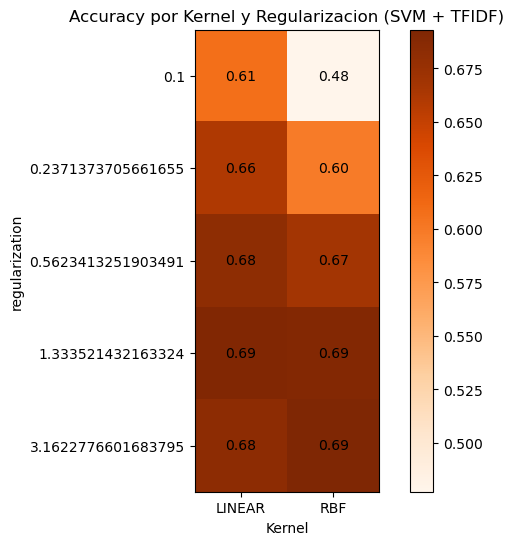

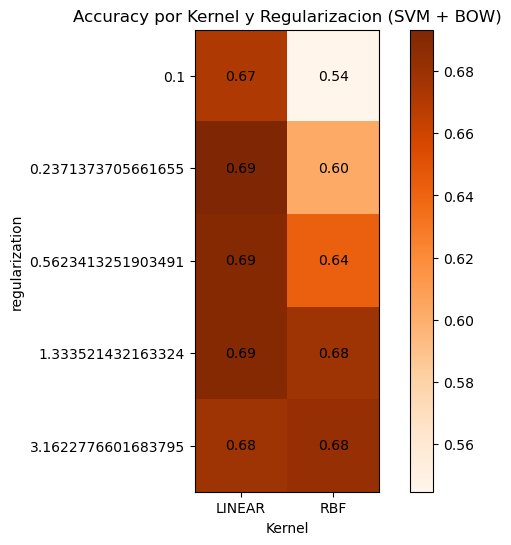

In [4]:
from constants.constants_tiktok import SVM_METRICS_PATH

# Cargar datos
df_svm = pd.read_csv(SVM_METRICS_PATH)
display(df_svm.head())

# Devidir información
df_svm_tfidf = df_svm[df_svm['vectorizer'] == 'TFIDF']
df_svm_bow = df_svm[df_svm['vectorizer'] == 'BOW']

# Obtener hiperparámetros
df_svm_tfidf_data = df_svm_tfidf.pivot(index="regularization", columns="kernel", values="accuracy")
df_svm_bow_data = df_svm_bow.pivot(index="regularization", columns="kernel", values="accuracy")

# Graficar
show_heatmap(df_svm_tfidf_data, "Kernel", "regularization", "Accuracy por Kernel y Regularizacion (SVM + TFIDF)")
show_heatmap(df_svm_bow_data, "Kernel", "regularization", "Accuracy por Kernel y Regularizacion (SVM + BOW)")

## NB

,accuracy,recall,precision,f1_score,model,vectorizer,alpha,vocab_size,train_time,name
0,0.612508,0.612460,0.608168,0.609221,NB,tfidf,0.001000,9046,0.146659,model_1
1,0.611149,0.611094,0.606365,0.606445,NB,bow,0.001000,9046,0.156028,model_2
2,0.613868,0.613818,0.609334,0.610451,NB,tfidf,0.001624,9046,0.125103,model_3
3,0.611829,0.611773,0.606834,0.607007,NB,bow,0.001624,9046,0.119918,model_4
4,0.614888,0.614838,0.610357,0.611430,NB,tfidf,0.002637,9046,0.155566,model_5


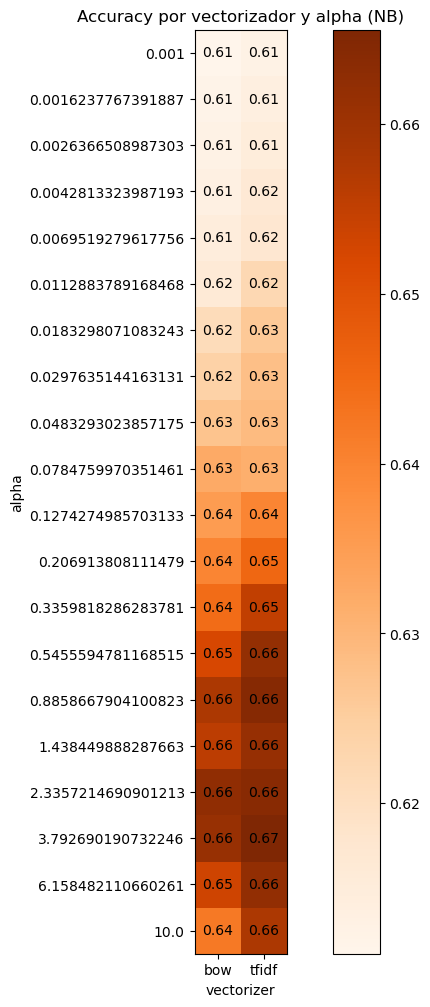

In [5]:
from constants.constants_tiktok import NB_METRICS_PATH

# Cargar datos
df_nb = pd.read_csv(NB_METRICS_PATH)

display(df_nb.head())

# Obtener hiperparámetros
df_nb_data = df_nb.pivot(index="alpha", columns="vectorizer", values="accuracy")

# Graficar
show_heatmap(df_nb_data, "vectorizer", "alpha", "Accuracy por vectorizador y alpha (NB)", (12,12))


## LR

,accuracy,recall,precision,f1_score,model,vectorizer,penalty,regularization,max_iter,solver,vocab_size,train_time,name
0,0.525833,0.525923,0.599882,0.512232,LR,TFIDF,l1,0.100000,200,saga,9046,0.399486,model_1
1,0.617947,0.617979,0.646821,0.619761,LR,BOW,l1,0.100000,200,saga,9046,4.859638,model_2
2,0.626105,0.626136,0.655710,0.628351,LR,TFIDF,l1,0.266073,200,saga,9046,0.456532,model_3
3,0.657036,0.657042,0.670115,0.659525,LR,BOW,l1,0.266073,200,saga,9046,10.869849,model_4
4,0.673012,0.673009,0.682276,0.675042,LR,TFIDF,l1,0.707946,200,saga,9046,1.487410,model_5


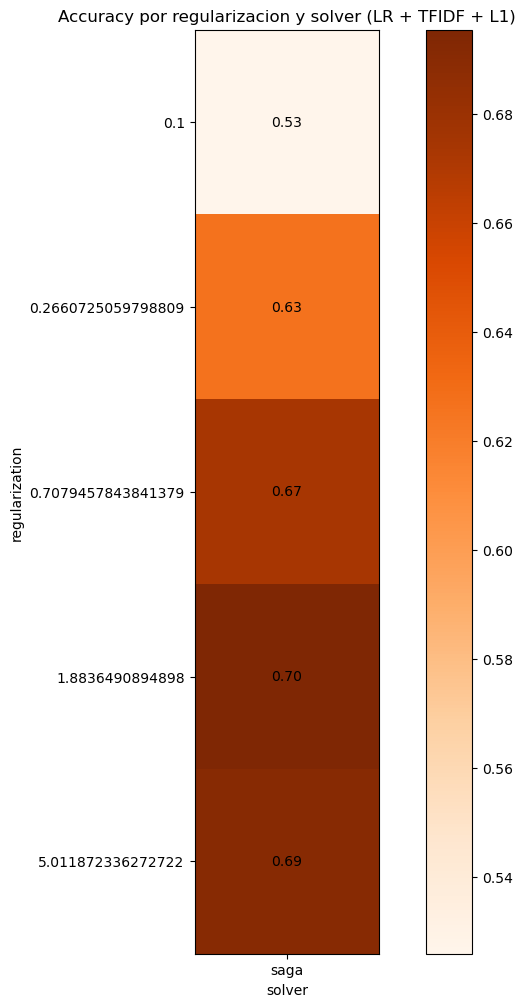

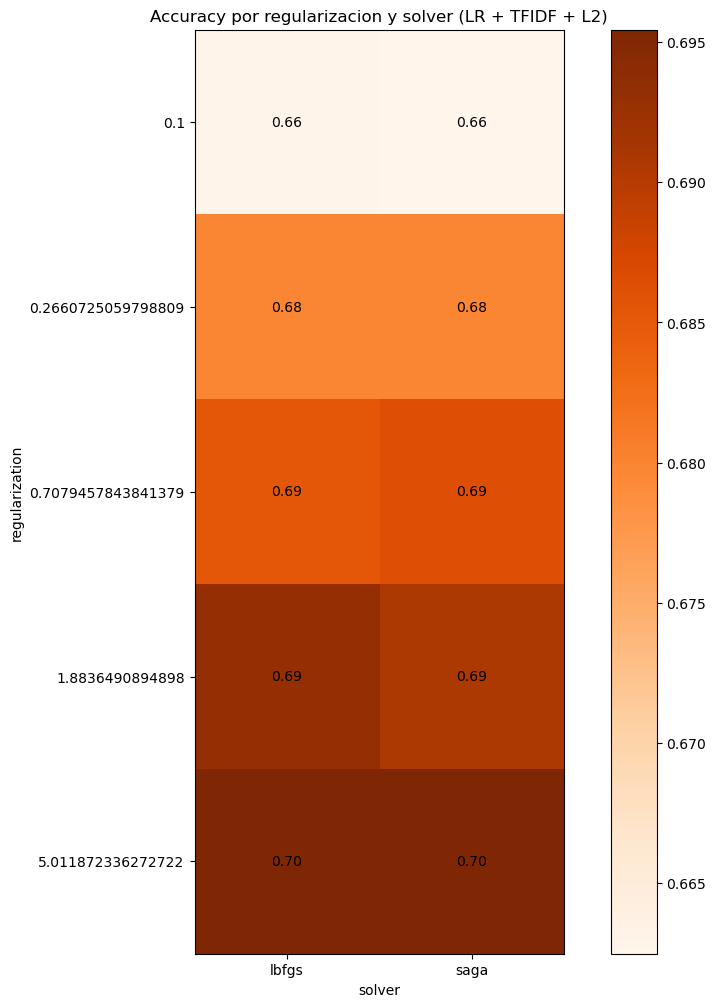

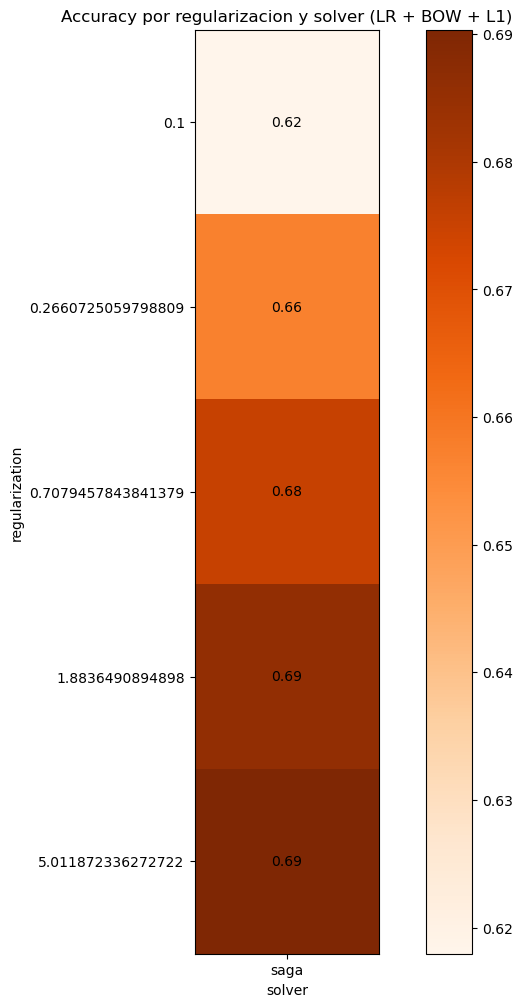

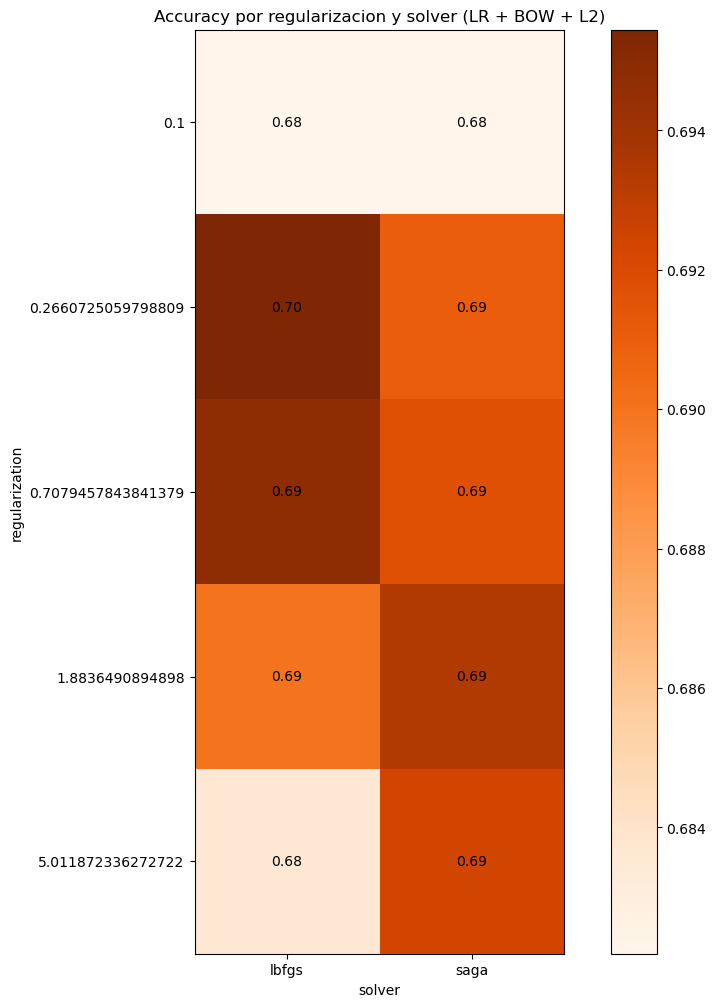

In [6]:
from constants.constants_tiktok import LR_METRICS_PATH

# Cargar datos
df_lr = pd.read_csv(LR_METRICS_PATH)
display(df_lr.head())

# Devidir información
df_lr_tfidf_l1 = df_lr[(df_lr['vectorizer'] == 'TFIDF') & (df_lr['penalty']=="l1")]
df_lr_tfidf_l2 = df_lr[(df_lr['vectorizer'] == 'TFIDF') & (df_lr['penalty']=="l2")]
df_lr_bow_l1 = df_lr[(df_lr['vectorizer'] == 'BOW') & (df_lr['penalty']=="l1")]
df_lr_bow_l2 = df_lr[(df_lr['vectorizer'] == 'BOW') & (df_lr['penalty']=="l2")]

# Obtener hiperparámetros
df_lr_tfidf_l1_data = df_lr_tfidf_l1.pivot(index="regularization", columns="solver", values="accuracy")
df_lr_tfidf_l2_data = df_lr_tfidf_l2.pivot(index="regularization", columns="solver", values="accuracy")
df_lr_bow_l1_data = df_lr_bow_l1.pivot(index="regularization", columns="solver", values="accuracy")
df_lr_bow_l2_data = df_lr_bow_l2.pivot(index="regularization", columns="solver", values="accuracy")

# Graficar
show_heatmap(df_lr_tfidf_l1_data, "solver", "regularization", "Accuracy por regularizacion y solver (LR + TFIDF + L1)", (12, 12))
show_heatmap(df_lr_tfidf_l2_data, "solver", "regularization", "Accuracy por regularizacion y solver (LR + TFIDF + L2)", (12, 12))
show_heatmap(df_lr_bow_l1_data, "solver", "regularization", "Accuracy por regularizacion y solver (LR + BOW + L1)", (12, 12))
show_heatmap(df_lr_bow_l2_data, "solver", "regularization", "Accuracy por regularizacion y solver (LR + BOW + L2)", (12, 12))

## SWEM

,accuracy,recall,precision,f1_score,model,classifier,pooling,penalty,kernel,regularization,max_iter,solver,embedding_dim,train_time,name
0,0.596873,0.596813,0.591525,0.590972,SWEM,svm,aver,NaN,linear,0.100000,NaN,NaN,100,19.296041,svm_model_1
1,0.563222,0.563187,0.560639,0.560873,SWEM,svm,max,NaN,linear,0.100000,NaN,NaN,100,20.901655,svm_model_2
2,0.631203,0.631166,0.628975,0.629293,SWEM,svm,aver,NaN,rbf,0.100000,NaN,NaN,100,24.848636,svm_model_3
3,0.585996,0.585961,0.584269,0.583954,SWEM,svm,max,NaN,rbf,0.100000,NaN,NaN,100,26.541972,svm_model_4
4,0.592114,0.592053,0.586815,0.586161,SWEM,svm,aver,NaN,linear,0.237137,NaN,NaN,100,19.386744,svm_model_5


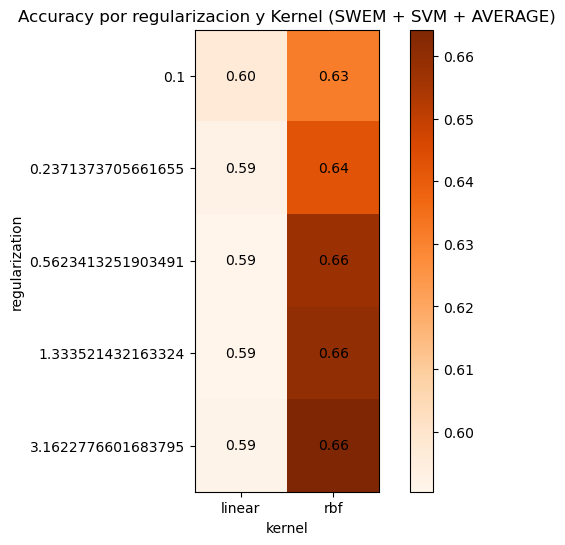

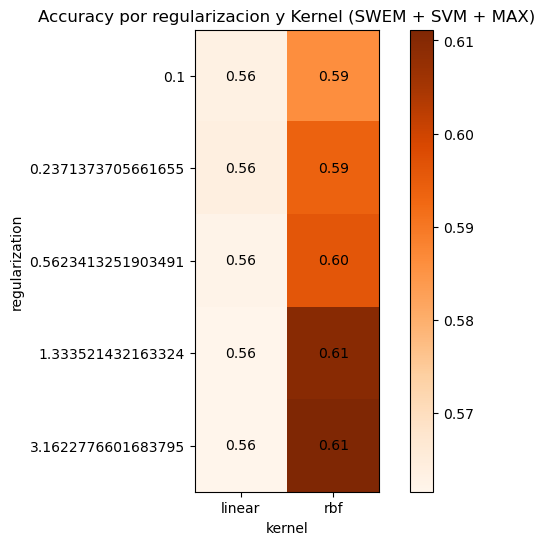

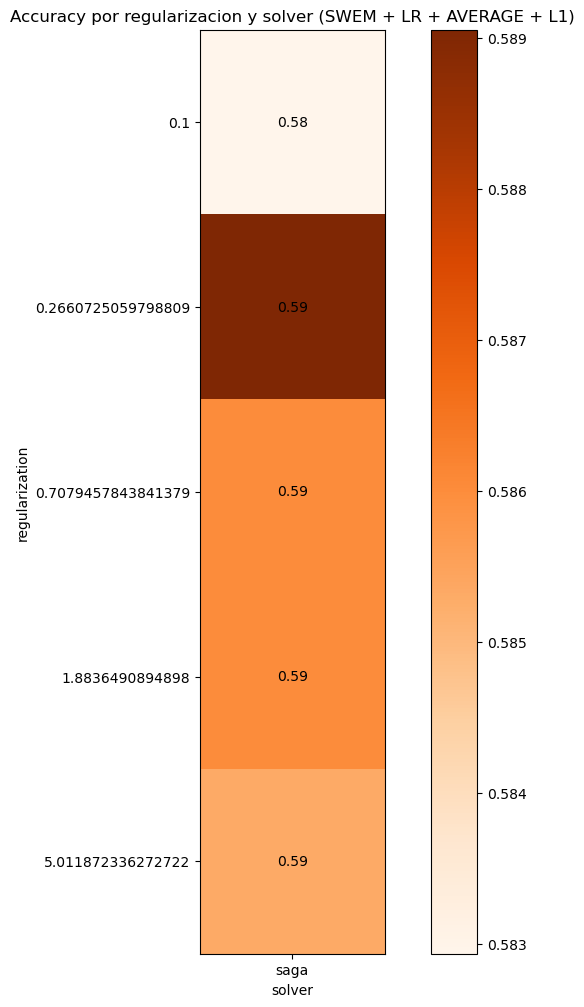

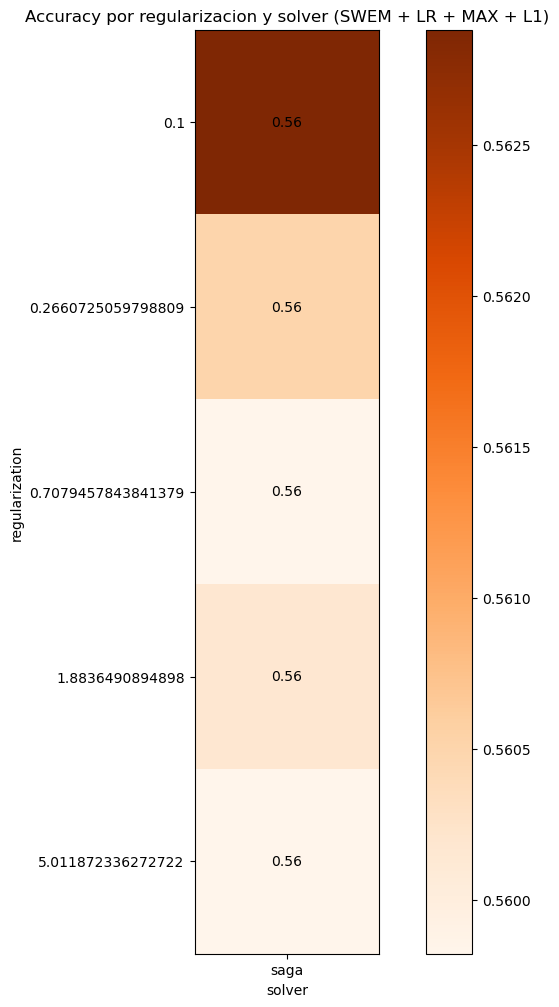

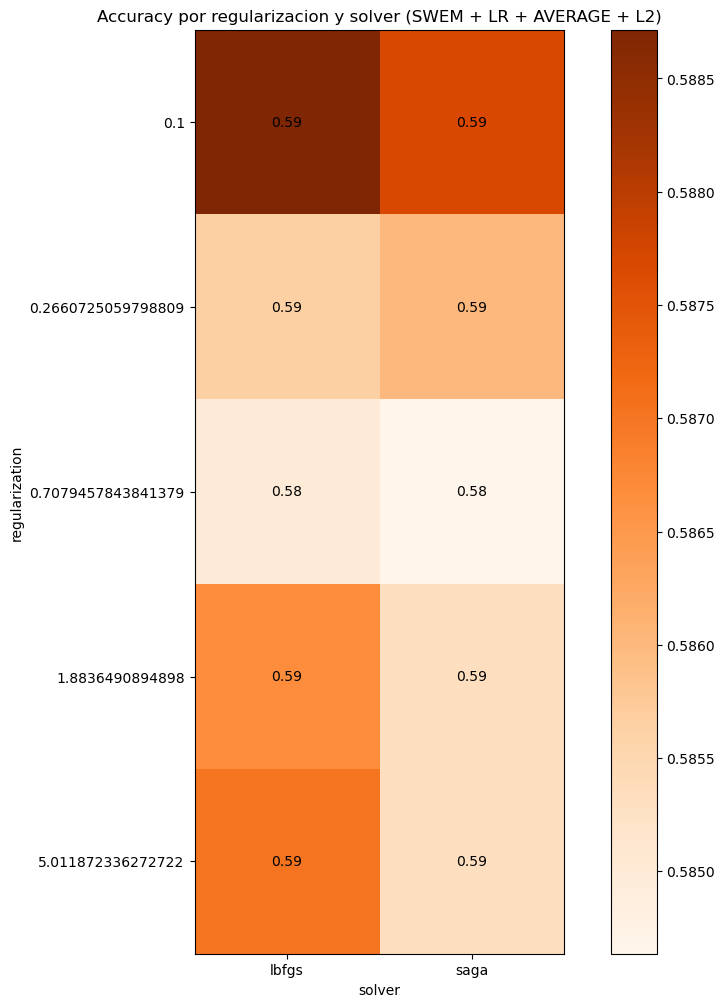

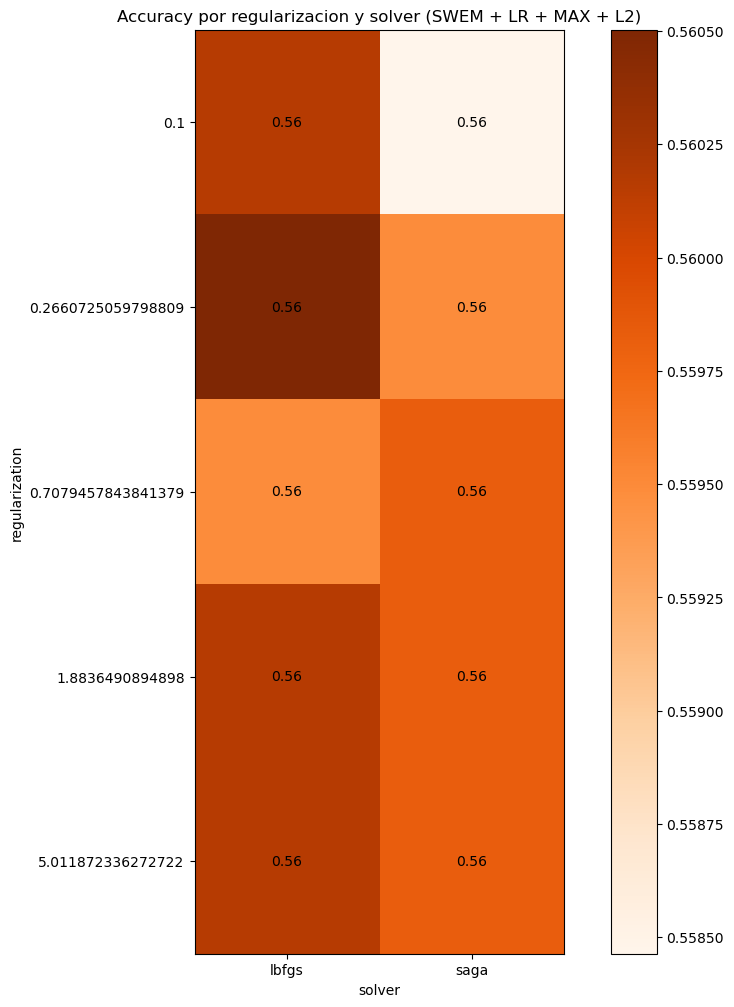

In [7]:

from constants.constants_tiktok import SWEM_METRICS_PATH

# Cargar datos
df_swem = pd.read_csv(SWEM_METRICS_PATH)
display(df_swem.head())

# Devidir información
df_swem_svm_aver = df_swem[(df_swem['classifier'] == 'svm') & (df_swem['pooling'] == "aver")]
df_swem_svm_max = df_swem[(df_swem['classifier'] == 'svm') & (df_swem['pooling'] == "max")]
df_swem_lr_aver_l1 = df_swem[(df_swem['classifier'] == 'lr') & (df_swem['pooling'] == "aver") & (df_swem['penalty'] == "l1")]
df_swem_lr_max_l1 = df_swem[(df_swem['classifier'] == 'lr') & (df_swem['pooling'] == "max") & (df_swem['penalty'] == "l1")]
df_swem_lr_aver_l2 = df_swem[(df_swem['classifier'] == 'lr') & (df_swem['pooling'] == "aver") & (df_swem['penalty'] == "l2")]
df_swem_lr_max_l2 = df_swem[(df_swem['classifier'] == 'lr') & (df_swem['pooling'] == "max") & (df_swem['penalty'] == "l2")]

# Obtener hiperparámetros
df_swem_svm_aver_data = df_swem_svm_aver.pivot(index="regularization", columns="kernel", values="accuracy")
df_swem_svm_max_data = df_swem_svm_max.pivot(index="regularization", columns="kernel", values="accuracy")
df_swem_lr_aver_l1_data = df_swem_lr_aver_l1.pivot(index="regularization", columns="solver", values="accuracy")
df_swem_lr_max_l1_data = df_swem_lr_max_l1.pivot(index="regularization", columns="solver", values="accuracy")
df_swem_lr_aver_l2_data = df_swem_lr_aver_l2.pivot(index="regularization", columns="solver", values="accuracy")
df_swem_lr_max_l2_data = df_swem_lr_max_l2.pivot(index="regularization", columns="solver", values="accuracy")

# Graficar
show_heatmap(df_swem_svm_aver_data, "kernel", "regularization", "Accuracy por regularizacion y Kernel (SWEM + SVM + AVERAGE)")
show_heatmap(df_swem_svm_max_data, "kernel", "regularization", "Accuracy por regularizacion y Kernel (SWEM + SVM + MAX)")
show_heatmap(df_swem_lr_aver_l1_data, "solver", "regularization", "Accuracy por regularizacion y solver (SWEM + LR + AVERAGE + L1)", (12,12))
show_heatmap(df_swem_lr_max_l1_data, "solver", "regularization", "Accuracy por regularizacion y solver (SWEM + LR + MAX + L1)", (12,12))
show_heatmap(df_swem_lr_aver_l2_data, "solver", "regularization", "Accuracy por regularizacion y solver (SWEM + LR + AVERAGE + L2)", (12,12))
show_heatmap(df_swem_lr_max_l2_data, "solver", "regularization", "Accuracy por regularizacion y solver (SWEM + LR + MAX + L2)", (12,12))

## MLP

,accuracy,recall,precision,f1_score,model,pooling,optim,lr,patience,min_delta,hidden_layers,output_size,dropout,epochs,batch_size,embedding_dim,train_time,name
0,0.636642,0.636627,0.639563,0.637457,MLP SWEM,aver,adam,0.001000,15,0.0001,"[128, 64]",3,0.2,25/200,64,100,12.140222,model_1
1,0.593474,0.593445,0.592311,0.590146,MLP SWEM,max,adam,0.001000,15,0.0001,"[128, 64]",3,0.2,23/200,64,100,10.460762,model_2
2,0.601292,0.601209,0.593789,0.587826,MLP SWEM,aver,sgd,0.001000,15,0.0001,"[128, 64]",3,0.2,200/200,64,100,85.684277,model_3
3,0.576139,0.576087,0.572625,0.570701,MLP SWEM,max,sgd,0.001000,15,0.0001,"[128, 64]",3,0.2,200/200,64,100,82.012527,model_4
4,0.636642,0.636606,0.634911,0.633190,MLP SWEM,aver,adam,0.001995,15,0.0001,"[128, 64]",3,0.2,21/200,64,100,10.664210,model_5


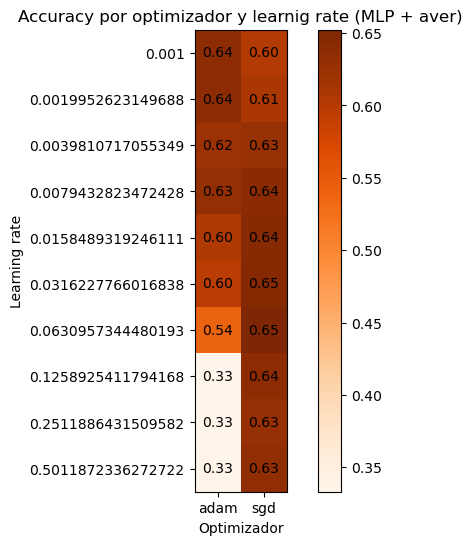

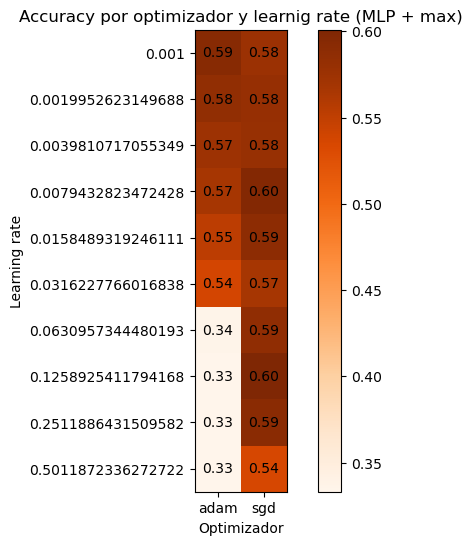

In [8]:
from constants.constants_tiktok import MLP_METRICS_PATH

# Cargar datos
df_mlp = pd.read_csv(MLP_METRICS_PATH)
display(df_mlp.head())

# Dividir informacion
df_mlp_aver = df_mlp[df_mlp['pooling'] == "aver"]
df_mlp_max = df_mlp[df_mlp['pooling'] == "max"]

# Obtener hiperparámetros
df_mlp_aver_data = df_mlp_aver.pivot(index="lr", columns="optim", values="accuracy")
df_mlp_max_data = df_mlp_max.pivot(index="lr", columns="optim", values="accuracy")

# Graficar
show_heatmap(df_mlp_aver_data, "Optimizador", "Learning rate", "Accuracy por optimizador y learnig rate (MLP + aver)")
show_heatmap(df_mlp_max_data, "Optimizador", "Learning rate", "Accuracy por optimizador y learnig rate (MLP + max)")


## RNN

,accuracy,recall,precision,f1_score,model,optim,lr,patience,min_delta,num_layers,hidden_size,dropout,epochs,batch_size,embedding_dim,train_time,name
0,0.579538,0.579515,0.578964,0.578837,RNN,adam,0.001000,15,0.0001,2,128,0.2,21/200,64,100,43.136700,model_1
1,0.627804,0.627770,0.625561,0.626050,RNN,sgd,0.001000,15,0.0001,2,128,0.2,182/200,64,100,359.459496,model_2
2,0.596873,0.596836,0.595994,0.595835,RNN,adam,0.001995,15,0.0001,2,128,0.2,21/200,64,100,41.653267,model_3
3,0.629844,0.629815,0.629621,0.629426,RNN,sgd,0.001995,15,0.0001,2,128,0.2,101/200,64,100,198.045723,model_4
4,0.601632,0.601582,0.604930,0.592448,RNN,adam,0.003981,15,0.0001,2,128,0.2,31/200,64,100,64.794670,model_5


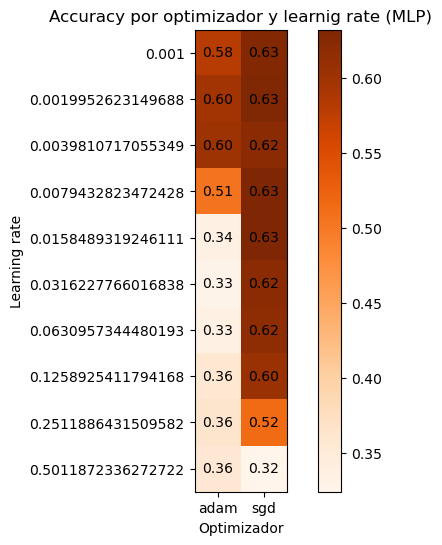

In [9]:
from constants.constants_tiktok import RNN_METRICS_PATH

# Cargar datos
df_rnn = pd.read_csv(RNN_METRICS_PATH)
display(df_rnn.head())

# Obtener hiperparámetros
df_rnn_data= df_rnn.pivot(index="lr", columns="optim", values="accuracy")

# Graficar
show_heatmap(df_rnn_data, "Optimizador", "Learning rate", "Accuracy por optimizador y learnig rate (MLP)")


## LSTM

,accuracy,recall,precision,f1_score,model,optim,lr,patience,min_delta,num_layers,hidden_size,dropout,epochs,batch_size,embedding_dim,train_time,name
0,0.660775,0.660752,0.660201,0.659953,LSTM,adam,0.001000,15,0.0001,2,128,0.2,200,64,100,46.530272,model_1
1,0.559143,0.559070,0.559007,0.547058,LSTM,sgd,0.001000,15,0.0001,2,128,0.2,200,64,100,434.282837,model_2
2,0.664174,0.664131,0.660802,0.660942,LSTM,adam,0.001995,15,0.0001,2,128,0.2,200,64,100,42.458589,model_3
3,0.606390,0.606339,0.600990,0.602033,LSTM,sgd,0.001995,15,0.0001,2,128,0.2,200,64,100,437.963568,model_4
4,0.677770,0.677740,0.677737,0.677570,LSTM,adam,0.003981,15,0.0001,2,128,0.2,200,64,100,40.267407,model_5


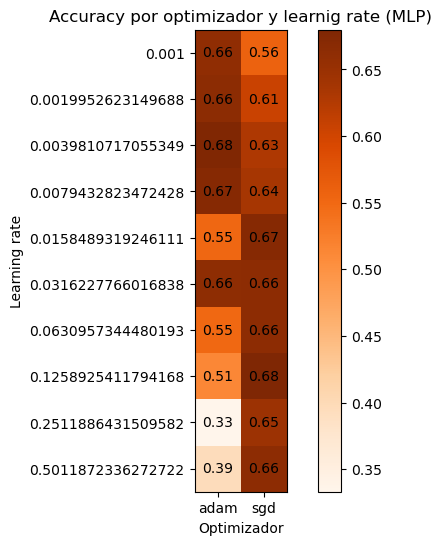

In [10]:
from constants.constants_tiktok import LSTM_METRICS_PATH

# Cargar datos
df_lstm = pd.read_csv(LSTM_METRICS_PATH)
display(df_lstm.head())

# Obtener hiperparámetros
df_lstm_data = df_lstm.pivot(index="lr", columns="optim", values="accuracy")

# Graficar
show_heatmap(df_lstm_data, "Optimizador", "Learning rate", "Accuracy por optimizador y learnig rate (MLP)")
